In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import os
import lakefs_spec

In [3]:
# Load data using lakefs
LAKEFS_REPO = "athletes"
lakefs_uri = lakefs_uri = f"lakefs://{LAKEFS_REPO}/v2/athletes_v2.csv"

# Open file using lakefs
fs = lakefs_spec.LakeFSFileSystem()

with fs.open(lakefs_uri, "rb") as f:
    df = pd.read_csv(f)

# Load data using DVC after git checkout v1 and dvc checkout
# df = pd.read_csv('athletes.csv')

print(f"Loaded dataset v2.")

Loaded dataset v2.


## Calculate total_lift and train-test split

In [5]:
# Total lift
df['total_lift'] = df['deadlift'] + df['candj'] + df['snatch'] + df['backsq']

In [6]:
# Train test split
df_train, df_test = train_test_split(df, test_size=0.2, random_state=32021)

## EDA

In [8]:
df.head()

,Unnamed: 0,region,gender,age,height,weight,candj,snatch,deadlift,backsq,eat,background,experience,schedule,howlong,total_lift
0,21,Southern California,Male,30.0,71.0,200.0,235.0,175.0,385.0,315.0,I eat whatever is convenient|,I played youth or high school level sports|I p...,I began CrossFit by trying it alone (without a...,I do multiple workouts in a day 1x a week|I ty...,1-2 years|,1110.0
1,22,Africa,Male,28.0,70.0,176.0,187.0,134.0,335.0,254.0,I eat 1-3 full cheat meals per week|,I have no athletic background besides CrossFit|,I began CrossFit with a coach (e.g. at an affi...,I do multiple workouts in a day 1x a week|,2-4 years|,910.0
2,27,North East,Male,35.0,68.0,225.0,285.0,205.0,440.0,405.0,I eat quality foods but don't measure the amount|,I played youth or high school level sports|,I began CrossFit with a coach (e.g. at an affi...,I typically rest 4 or more days per month|,2-4 years|,1335.0
3,50,North Central,Male,36.0,71.0,199.0,267.0,212.0,485.0,390.0,I eat quality foods but don't measure the amount|,I played youth or high school level sports|I p...,I began CrossFit with a coach (e.g. at an affi...,I do multiple workouts in a day 3+ times a wee...,1-2 years|,1354.0
4,60,North East,Male,36.0,64.0,155.0,245.0,180.0,415.0,385.0,I eat strict Paleo|,I played youth or high school level sports|I p...,I began CrossFit by trying it alone (without a...,I do multiple workouts in a day 2x a week|I st...,4+ years|,1225.0


In [9]:
print("Train data shape:", df_train.shape)
df_train.info()

Train data shape: (24128, 16)
<class 'pandas.core.frame.DataFrame'>
Int64Index: 24128 entries, 18656 to 8684
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  24128 non-null  int64  
 1   region      24128 non-null  object 
 2   gender      24128 non-null  object 
 3   age         24128 non-null  float64
 4   height      24128 non-null  float64
 5   weight      24128 non-null  float64
 6   candj       24128 non-null  float64
 7   snatch      24128 non-null  float64
 8   deadlift    24128 non-null  float64
 9   backsq      24128 non-null  float64
 10  eat         24128 non-null  object 
 11  background  24128 non-null  object 
 12  experience  24128 non-null  object 
 13  schedule    24128 non-null  object 
 14  howlong     24128 non-null  object 
 15  total_lift  24128 non-null  float64
dtypes: float64(8), int64(1), object(7)
memory usage: 3.1+ MB


In [10]:
# Missing values
df_train.isnull().sum()

Unnamed: 0    0
region        0
gender        0
age           0
height        0
weight        0
candj         0
snatch        0
deadlift      0
backsq        0
eat           0
background    0
experience    0
schedule      0
howlong       0
total_lift    0
dtype: int64

In [11]:
# Summary statistics
df_train.describe()

,Unnamed: 0,age,height,weight,candj,snatch,deadlift,backsq,total_lift
count,24128.000000,24128.000000,24128.000000,24128.000000,24128.000000,24128.000000,24128.00000,24128.000000,24128.000000
mean,112285.447779,32.108505,68.856432,177.091844,205.311257,156.065526,361.88992,294.041156,1017.307858
std,79368.170451,7.431855,3.780353,32.469278,58.757223,48.893735,96.96732,85.287526,278.348614
min,22.000000,18.000000,52.000000,28.000000,1.000000,1.000000,0.00000,1.000000,4.000000
25%,45848.500000,27.000000,66.000000,155.000000,160.000000,120.000000,287.00000,225.000000,805.000000
50%,95435.000000,31.000000,69.000000,178.000000,205.000000,155.000000,370.00000,300.000000,1038.000000
75%,167268.250000,37.000000,72.000000,196.000000,245.000000,190.000000,435.00000,355.000000,1225.000000
max,422961.000000,56.000000,83.000000,474.000000,386.000000,386.000000,1000.00000,882.000000,2135.000000


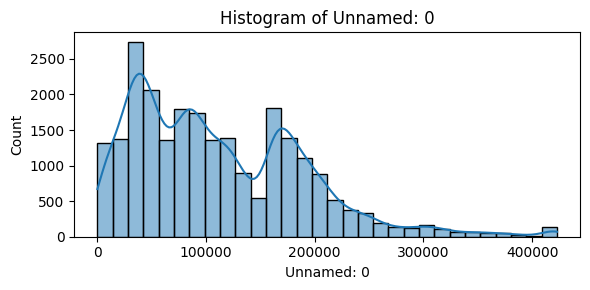

<Figure size 600x300 with 0 Axes>

<Figure size 600x300 with 0 Axes>

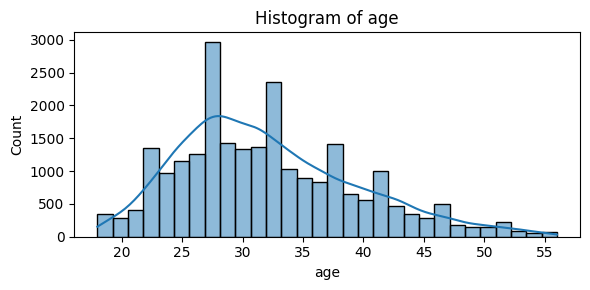

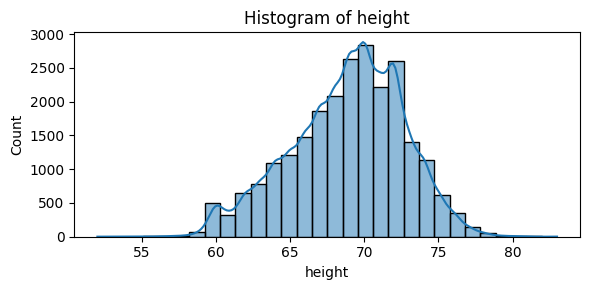

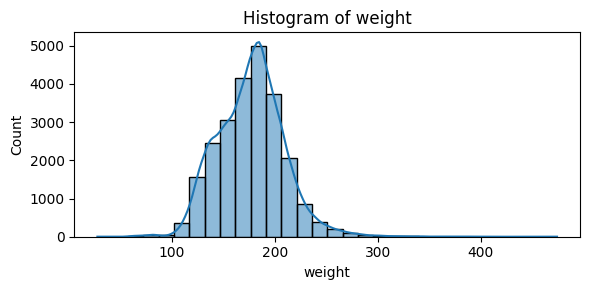

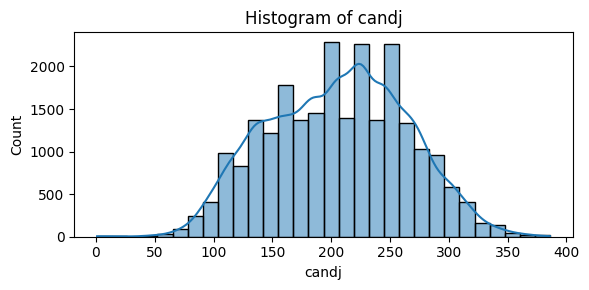

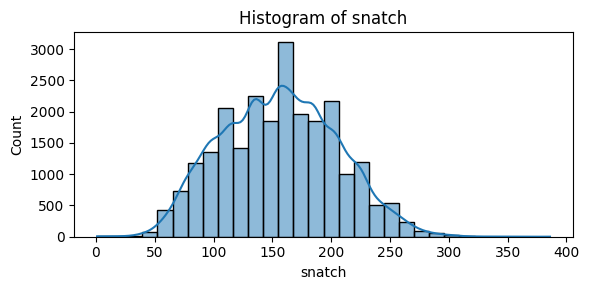

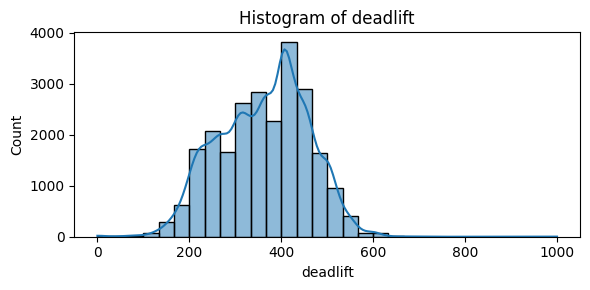

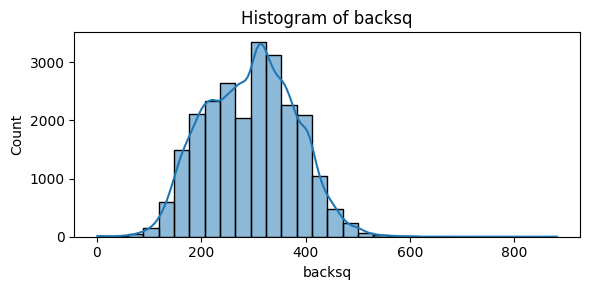

<Figure size 600x300 with 0 Axes>

<Figure size 600x300 with 0 Axes>

<Figure size 600x300 with 0 Axes>

<Figure size 600x300 with 0 Axes>

<Figure size 600x300 with 0 Axes>

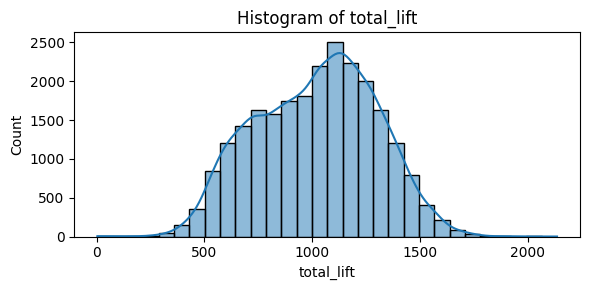

In [12]:
for col in df_train.columns:
    plt.figure(figsize=(6, 3))
    
    if df_train[col].dtype in ['int64', 'float64']:
        sns.histplot(df_train[col], kde=True, bins=30)
        plt.title(f'Histogram of {col}')
    plt.tight_layout()
    plt.show()

/var/folders/kf/8ms7_h8j11bf86d6c5ykldrw0000gn/T/ipykernel_54680/4151145974.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_mat = df_train.corr()


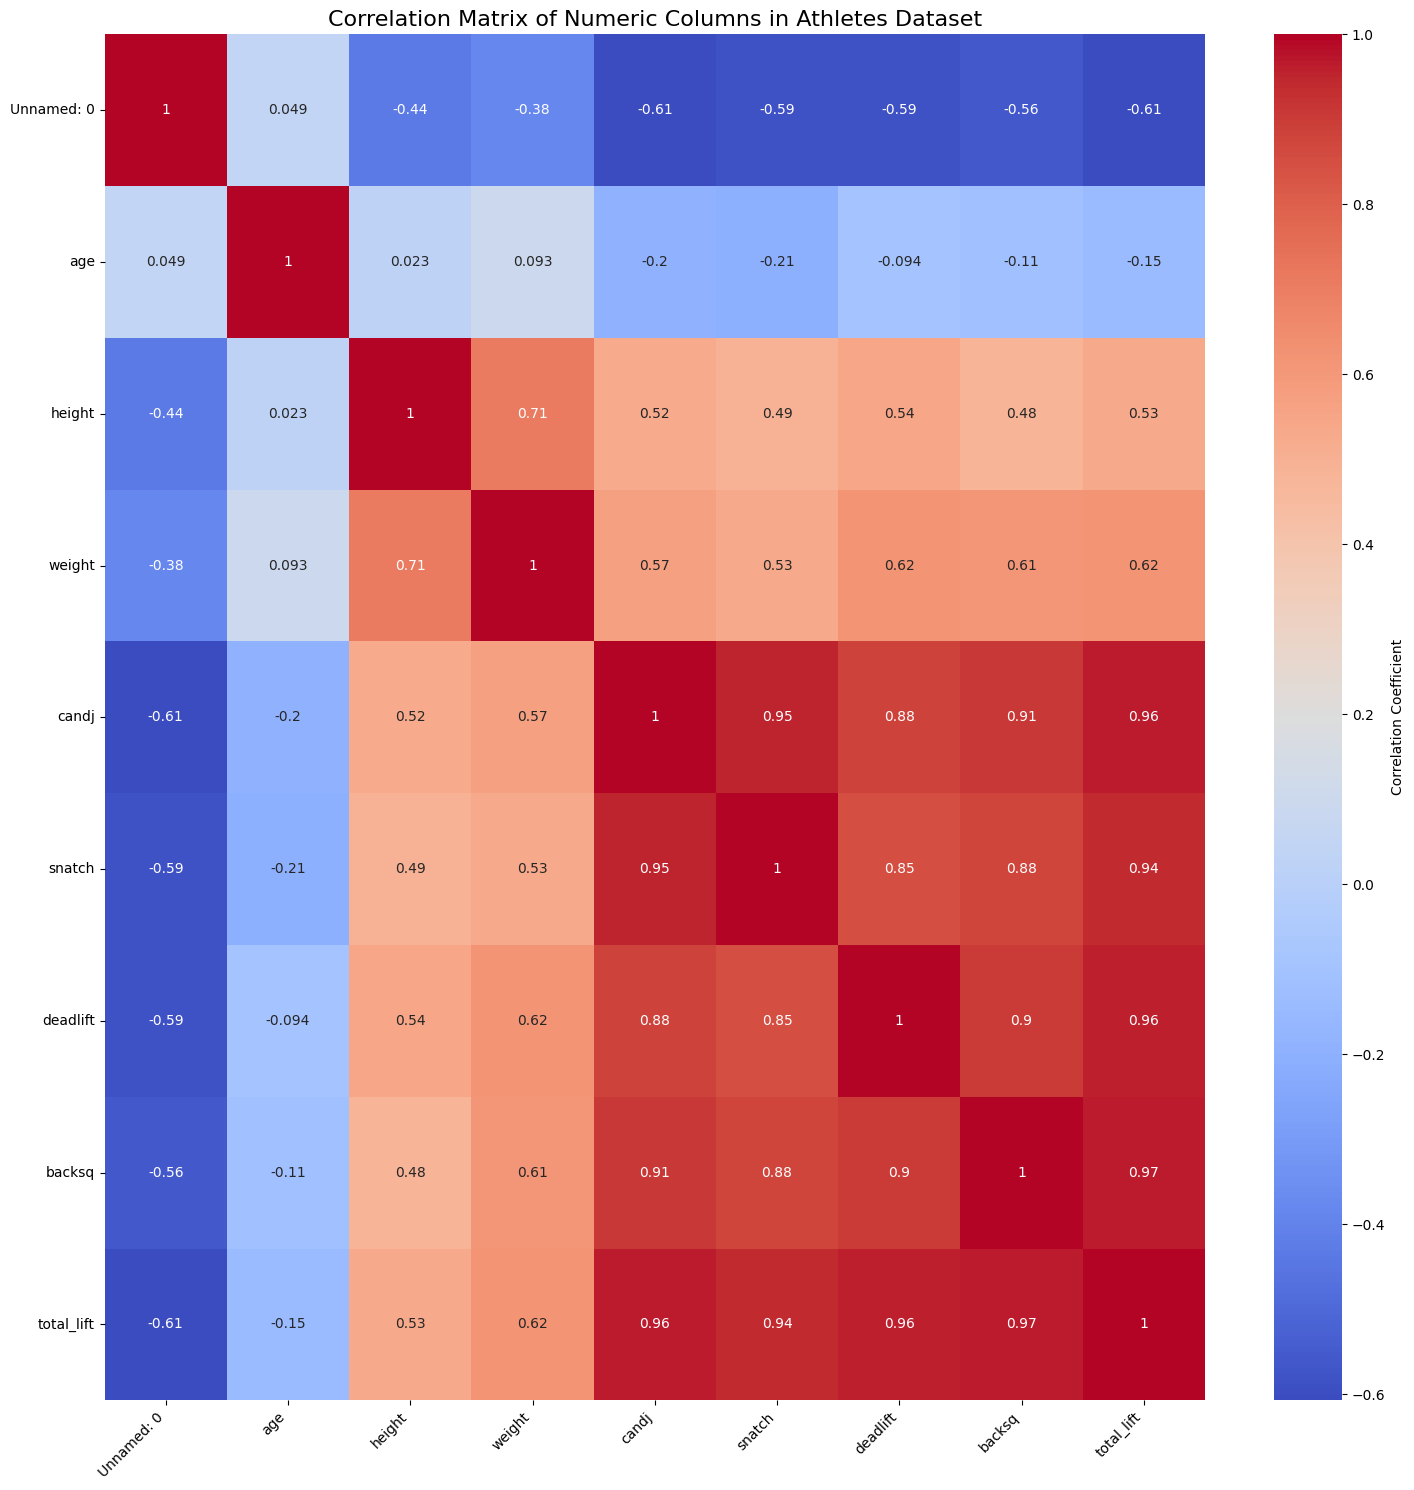

In [13]:
corr_mat = df_train.corr()

plt.figure(figsize=(15, 15))
sns.heatmap(corr_mat,annot=True,cmap='coolwarm',cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Matrix of Numeric Columns in Athletes Dataset', fontsize=16)
plt.xticks(rotation=45, ha='right') 
plt.yticks(rotation=0)      
plt.tight_layout()
plt.show()

## Model

In [15]:
df_train = df_train.dropna(subset=['total_lift'])
df_test = df_test.dropna(subset=['total_lift'])

target = 'total_lift'

X_train = df_train.drop(columns=[target])
y_train = df_train[target]

X_test = df_test.drop(columns=[target])
y_test = df_test[target]

In [16]:
# Numeric and categorical predictors
num_vars = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_vars = ['gender','howlong']

In [17]:
# Keep only relevant predictors
X_train = X_train[num_vars + cat_vars]
X_test = X_test[num_vars + cat_vars]

num_imputer = SimpleImputer(strategy='median')
X_train[num_vars] = num_imputer.fit_transform(X_train[num_vars])
X_test[num_vars] = num_imputer.transform(X_test[num_vars])

cat_imputer = SimpleImputer(strategy='most_frequent')
X_train[cat_vars] = cat_imputer.fit_transform(X_train[cat_vars])
X_test[cat_vars] = cat_imputer.transform(X_test[cat_vars])

In [18]:
# Encode categorical
X_train = pd.get_dummies(X_train, columns=cat_vars)
X_test = pd.get_dummies(X_test, columns=cat_vars)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [19]:
model = RandomForestRegressor(random_state=32021)
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Metrics:")
print("R^2 score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mse)
print("RMSE:", rmse)

Metrics:
R^2 score: 0.9986414171653982
MAE: 4.422226089839219
MSE: 103.16166091496771
RMSE: 10.156852904072585


#### Model comparision to v1:
The model metrics using data version 2 is much better than version 1. The R^2 is much higher while MAE, MSE, and RMSE are significantly lower compared to version 1.